In [ ]:
from pathlib import Path
import pandas as pd
#Path dos dados baixados
DATA_DIR = Path("C:/Users/Cliente/Downloads/pós-graduacao/trabalho-final-fase-1/data/raw")
# listar arquivos .csv
csv_files = list(DATA_DIR.glob("*.csv"))

csv_files
#criar df
df = pd.read_csv(csv_files[0])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
df.shape

(7043, 21)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.columns.tolist()


['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [23]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [ ]:
#contagem de churn
display(df["Churn"].value_counts())
#porcentagem de churn
display(df["Churn"].value_counts(normalize=True) * 100)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

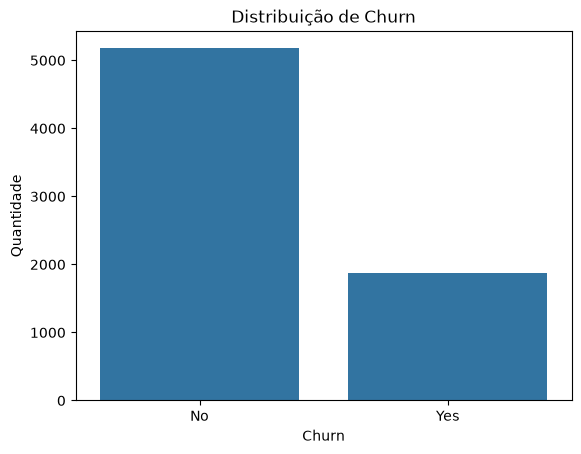

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn")

plt.title("Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade")

plt.show()

In [34]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [39]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
df["TotalCharges"]

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [41]:
df = df.drop(columns=["customerID"])

KeyError: "['customerID'] not found in axis"

In [42]:
numeric_columns = df.select_dtypes(
    include="number"
).columns

numeric_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

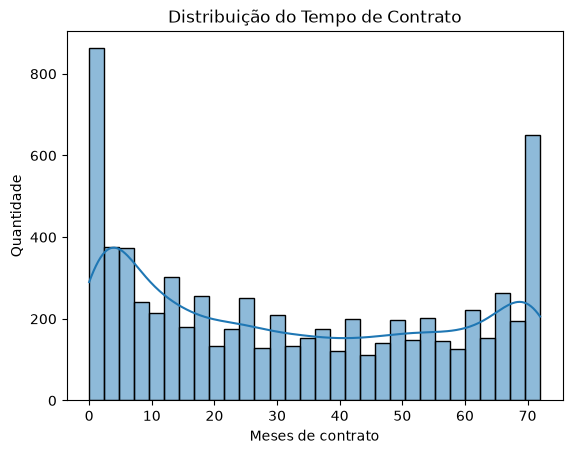

In [43]:
sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribuição do Tempo de Contrato")
plt.xlabel("Meses de contrato")
plt.ylabel("Quantidade")

plt.show()

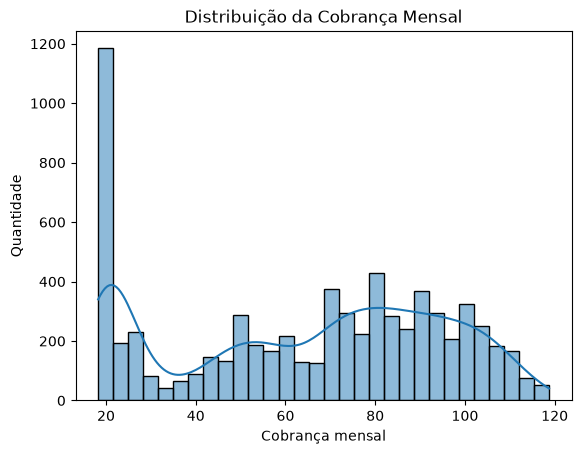

In [45]:
sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribuição da Cobrança Mensal")
plt.xlabel("Cobrança mensal")
plt.ylabel("Quantidade")

plt.show()

In [46]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [47]:
churn_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


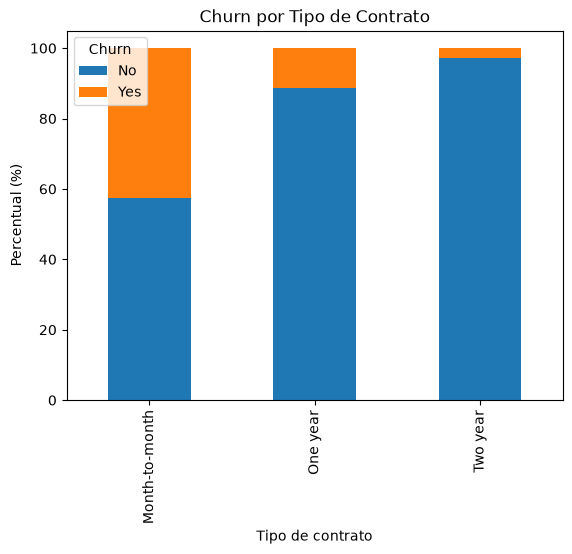

In [48]:
churn_contract.plot(
    kind="bar",
    stacked=True
)

plt.title("Churn por Tipo de Contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Percentual (%)")

plt.show()

In [49]:
churn_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

churn_internet

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


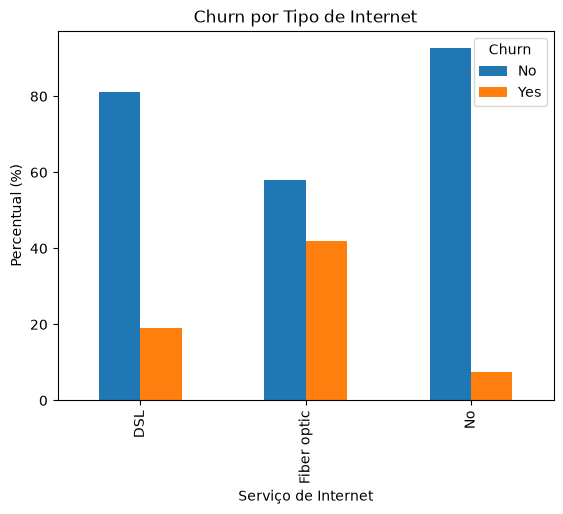

In [50]:
churn_internet.plot(
    kind="bar"
)

plt.title("Churn por Tipo de Internet")
plt.xlabel("Serviço de Internet")
plt.ylabel("Percentual (%)")

plt.show()

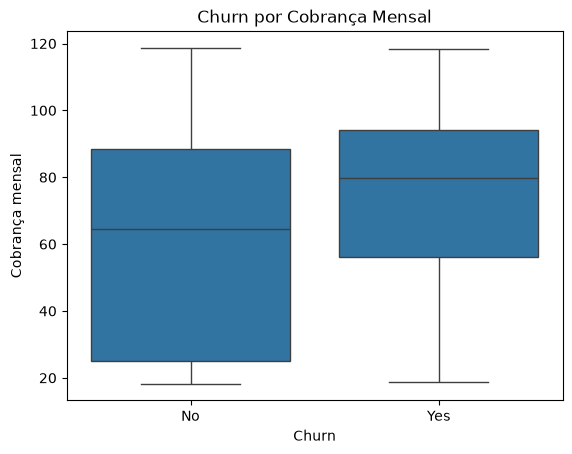

In [51]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Churn por Cobrança Mensal")
plt.xlabel("Churn")
plt.ylabel("Cobrança mensal")

plt.show()

In [52]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [53]:
correlation = df.select_dtypes(
    include="number"
).corr()

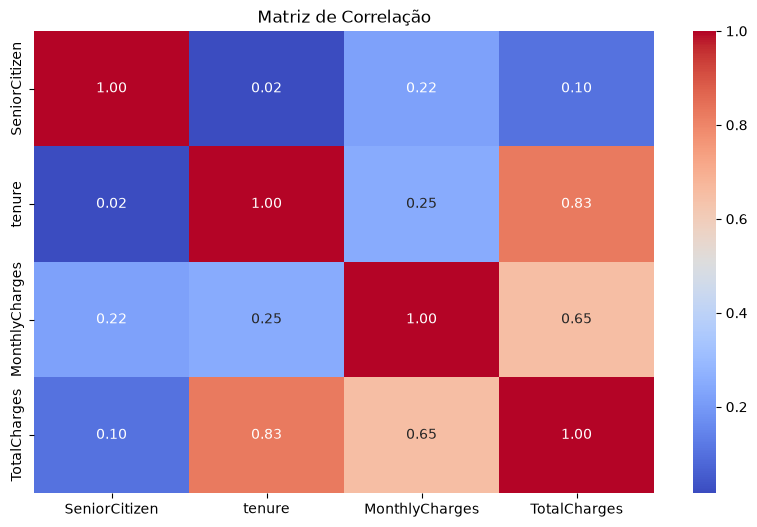

In [54]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()

In [55]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [56]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [57]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [ ]:
#0 = No Churn
#1 = Churn
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [61]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

In [62]:
print("Numéricas:")
print(numeric_features)

print("\nCategóricas:")
print(categorical_features)

Numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [72]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

In [71]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_pipeline.fit(
    X_train,
    y_train
)


rf_scores = cross_val_score(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)


In [70]:
from sklearn.neural_network import MLPClassifier

mlp_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=500,
            early_stopping=True,
            random_state=42
        )
    )
])

mlp_pipeline.fit(
    X_train,
    y_train
)

mlp_scores = cross_val_score(
    mlp_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

In [73]:
from sklearn.model_selection import cross_val_score

results = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest",
        "MLP"
    ],
    "ROC-AUC Médio": [
        logistic_scores.mean(),
        rf_scores.mean(),
        mlp_scores.mean()
    ],
    "Desvio Padrão": [
        logistic_scores.std(),
        rf_scores.std(),
        mlp_scores.std()
    ]
})

results

,Modelo,ROC-AUC Médio,Desvio Padrão
0,Logistic Regression,0.845562,0.013874
1,Random Forest,0.823981,0.012131
2,MLP,0.841440,0.015429


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [75]:
model = random_forest_pipeline

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)

y_proba = model.predict_proba(
    X_test
)[:, 1]

In [77]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(y_test, y_pred)
)

print(
    "Recall:",
    recall_score(y_test, y_pred)
)

print(
    "F1:",
    f1_score(y_test, y_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_proba)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.7785663591199432
Precision: 0.6061643835616438
Recall: 0.4732620320855615
F1: 0.5315315315315315
ROC-AUC: 0.817131674804309
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

